In [108]:
import pandas as pd
import numpy as np


In [109]:
data = pd.read_csv("DST_BIL54.csv")

# Parse month strings to UTC timestamps at first of month.
data["time"] = pd.to_datetime(data["time"] + "-01", format="%Y-%m-%d", utc=True)

# Year with fractional month component.
data["year"] = data["time"].dt.year + (data["time"].dt.month - 1) / 12

# Convert to millions.
data["total"] = pd.to_numeric(data["total"], errors="coerce") / 1e6

# Drop all other columns
data = data[["time", "year", "total"]]

# Train/test split.
teststart = pd.Timestamp("2024-01-01", tz="UTC")
Dtrain = data[data["time"] < teststart]
Dtest = data[data["time"] >= teststart]

Dtrain.head()


,time,year,total
0,2018-01-01 00:00:00+00:00,2018.000000,2.930483
1,2018-02-01 00:00:00+00:00,2018.083333,2.934044
2,2018-03-01 00:00:00+00:00,2018.166667,2.941422
3,2018-04-01 00:00:00+00:00,2018.250000,2.951498
4,2018-05-01 00:00:00+00:00,2018.333333,2.963093


## 1.1. Plot Training Data vs Time (x)

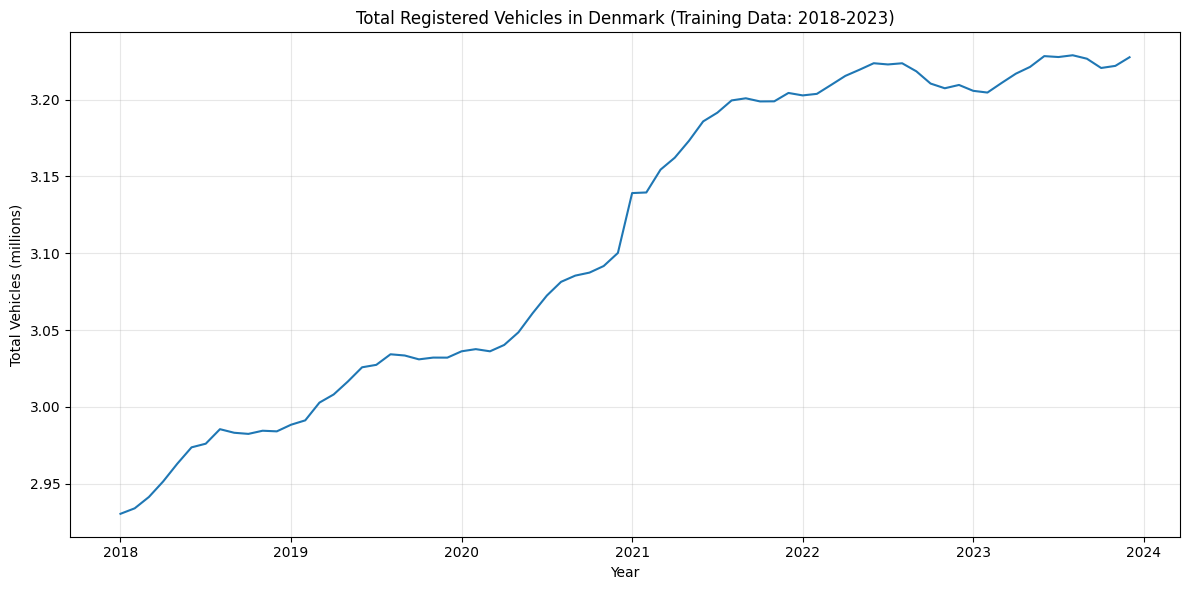

In [110]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(Dtrain["year"], Dtrain["total"], linewidth=1.5)
plt.xlabel("Year")
plt.ylabel("Total Vehicles (millions)")
plt.title("Total Registered Vehicles in Denmark (Training Data: 2018-2023)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 1.2. Time Series Description

**Observations:**

The time series shows the total number of registered vehicles in Denmark from 2018 to the end of 2023, measured in millions. Several key features are evident:

1. **Overall Trend**: There is a clear upward trend throughout the period, with the total number of vehicles increasing from approximately 2.93 million in early 2018 to about 3.23 million by the end of 2023.

2. **Growth Pattern**: The growth is not uniform:
   - **2018-2020**: Steady moderate growth with a relatively smooth trajectory
   - **2020-2021**: A period of accelerated growth with a noticeable increase in the rate of vehicle registrations
   - **2021-2022**: Sharp increase, particularly visible around mid-2021, where the series shows a steep upward movement
   - **2022-2023**: The growth rate slows down, and the series appears to level off somewhat, showing a slight plateau or oscillatory behavior around 3.2 million vehicles

3. **Potential Seasonality**: There appear to be some minor fluctuations or oscillations superimposed on the trend, which could indicate seasonal patterns in vehicle registrations.

4. **Recent Behavior**: In 2023, the series shows less pronounced growth compared to 2021-2022, with small ups and downs, suggesting potential market saturation or changes in registration patterns.

Overall, this is a non-stationary time series with a strong positive trend and possible seasonal components.

## 2. Linear Trend Model


### General Matrix Form

The linear trend model can be written as:

**y = Xθ + ϵ**

where:
- **y** is the N × 1 vector of observations
- **X** is the N × 2 design matrix
- **θ** is the 2 × 1 parameter vector
- **ϵ** is the N × 1 error vector with ϵ ∼ N(0, σ²I)

#### 1. Vector/Matrix Form:
```
[y] = [X][θ]+ [ϵ]
```

#### 2. With Element Notation:
```
⎡y₁⎤   ⎡1  x₁⎤ ⎡θ₁⎤   ⎡ϵ₁⎤
⎢y₂⎥ = ⎢1  x₂⎥ ⎢θ₂⎥ + ⎢ϵ₂⎥
⎣y₃⎦   ⎣1  x₃⎦ ⎣  ⎦   ⎣ϵ₃⎦

where:
- y₁, y₂, y₃ are the observed total vehicles (in millions)
- x₁, x₂, x₃ are the time values
- θ₁ is the intercept
- θ₂ is the slope (trend coefficient)
- ϵ₁, ϵ₂, ϵ₃ are the error terms
```

In [111]:
print("First 3 observations:")
print(Dtrain[["year", "total"]].head(3))
print("\nActual values (rounded to 3 digits):")
print(f"x₁ = {Dtrain['year'].iloc[0]:.3f}, y₁ = {Dtrain['total'].iloc[0]:.3f}")
print(f"x₂ = {Dtrain['year'].iloc[1]:.3f}, y₂ = {Dtrain['total'].iloc[1]:.3f}")
print(f"x₃ = {Dtrain['year'].iloc[2]:.3f}, y₃ = {Dtrain['total'].iloc[2]:.3f}")

First 3 observations:
          year     total
0  2018.000000  2.930483
1  2018.083333  2.934044
2  2018.166667  2.941422

Actual values (rounded to 3 digits):
x₁ = 2018.000, y₁ = 2.930
x₂ = 2018.083, y₂ = 2.934
x₃ = 2018.167, y₃ = 2.941


```
⎡2.933⎤   ⎡1  2018.000⎤ ⎡θ₁⎤   ⎡ϵ₁⎤
⎢2.938⎥ = ⎢1  2018.083⎥ ⎢θ₂⎥ + ⎢ϵ₂⎥
⎣2.943⎦   ⎣1  2018.167⎦ ⎣  ⎦   ⎣ϵ₃⎦
```

## 3. OLS - Global Linear Trend Model

In [112]:
## 3.1. OLS Parameter Estimation

# Construct the design matrix X and output vector y
X = np.column_stack([np.ones(len(Dtrain)), Dtrain["year"]])
y = Dtrain["total"].values

# OLS estimate: θ̂ = (X'X)^(-1) X'y
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("OLS Parameter Estimates:")
print(f"θ̂₁ (intercept) = {theta_hat[0]:.6f}")
print(f"θ̂₂ (slope)     = {theta_hat[1]:.6f}")

# Interpretation
print("\n" + "="*60)
print("Interpretation:")
print("="*60)
print(f"Intercept (θ̂₁): {theta_hat[0]:.3f} million vehicles")
print(f"Trend (θ̂₂):     {theta_hat[1]:.6f} million vehicles per year")
print(f"\nThe model estimates that vehicle registrations increase by")
print(f"approximately {theta_hat[1]*1000:.1f} thousand vehicles per year.")

OLS Parameter Estimates:
θ̂₁ (intercept) = -110.355428
θ̂₂ (slope)     = 0.056145

Interpretation:
Intercept (θ̂₁): -110.355 million vehicles
Trend (θ̂₂):     0.056145 million vehicles per year

The model estimates that vehicle registrations increase by
approximately 56.1 thousand vehicles per year.


In [113]:
## 3.2. Parameter Estimates with Standard Errors

# Calculate residuals
y_hat = X @ theta_hat
residuals = y - y_hat

# Estimate residual variance: σ̂² = (1/(N-p)) * Σeᵢ²
N = len(y)
p = 2  # number of parameters
sigma_squared_hat = np.sum(residuals**2) / (N - p)

# Covariance matrix of parameter estimates: Var(θ̂) = σ̂² * (X'X)⁻¹
cov_theta = sigma_squared_hat * np.linalg.inv(X.T @ X)

# Standard errors are square roots of diagonal elements
se_theta = np.sqrt(np.diag(cov_theta))

# Display results
print("="*70)
print("OLS PARAMETER ESTIMATES WITH STANDARD ERRORS")
print("="*70)
print(f"θ̂₁ (intercept) = {theta_hat[0]:12.6f}  ±  {se_theta[0]:.6f}")
print(f"θ̂₂ (slope)     = {theta_hat[1]:12.6f}  ±  {se_theta[1]:.6f}")
print(f"\nResidual standard deviation (σ̂) = {np.sqrt(sigma_squared_hat):.6f} million vehicles")
print(f"Degrees of freedom = {N - p}")
print("="*70)

# Calculate t-statistics and p-values (optional but informative)
t_stats = theta_hat / se_theta
from scipy import stats
p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), N - p))

print("\nStatistical Significance:")
print(f"t-statistic for θ₁: {t_stats[0]:.3f}, p-value: {p_values[0]:.6f}")
print(f"t-statistic for θ₂: {t_stats[1]:.3f}, p-value: {p_values[1]:.6f}")

OLS PARAMETER ESTIMATES WITH STANDARD ERRORS
θ̂₁ (intercept) =  -110.355428  ±  3.593581
θ̂₂ (slope)     =     0.056145  ±  0.001778

Residual standard deviation (σ̂) = 0.026131 million vehicles
Degrees of freedom = 70

Statistical Significance:
t-statistic for θ₁: -30.709, p-value: 0.000000
t-statistic for θ₂: 31.575, p-value: 0.000000


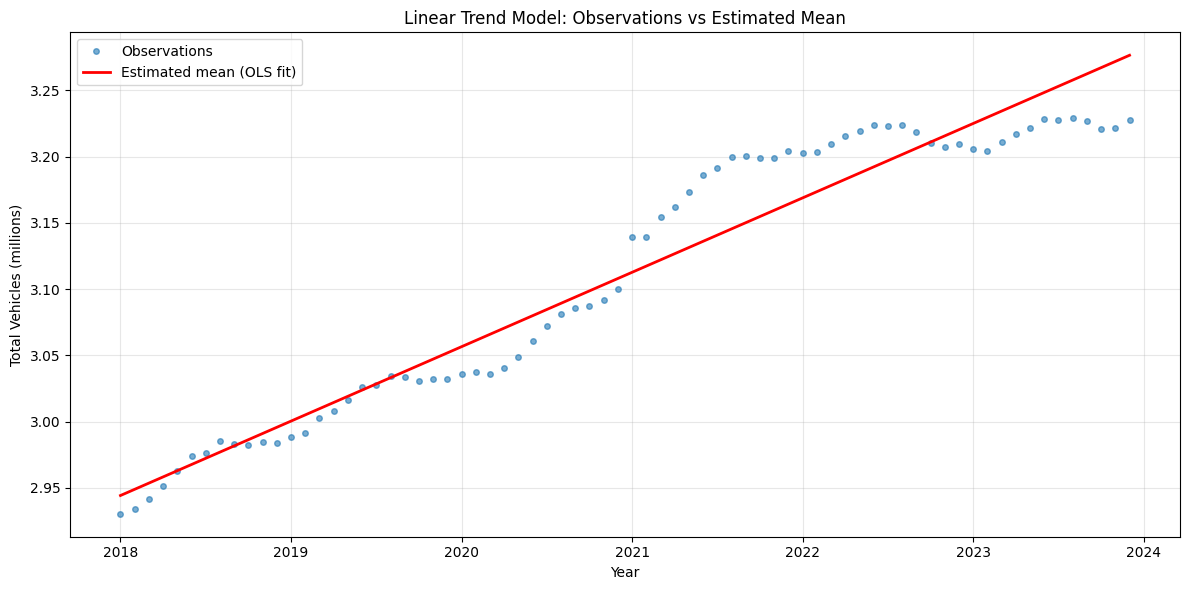


Estimated Model:
ŷ = -110.355428 + 0.056145 × year


In [114]:
## 3.2. Plot: Observations and Estimated Mean

plt.figure(figsize=(12, 6))

# Plot observations as points
plt.plot(Dtrain["year"], Dtrain["total"], 'o', 
         markersize=4, alpha=0.6, label='Observations')

# Plot estimated mean as a line
plt.plot(Dtrain["year"], y_hat, '-', 
         linewidth=2, color='red', label='Estimated mean (OLS fit)')

plt.xlabel("Year")
plt.ylabel("Total Vehicles (millions)")
plt.title("Linear Trend Model: Observations vs Estimated Mean")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print model equation
print(f"\nEstimated Model:")
print(f"ŷ = {theta_hat[0]:.6f} + {theta_hat[1]:.6f} × year")

In [115]:
# Make a forecast for the test set (2024-Jan to 2024-Dec) with 95% prediction intervals

# Design matrix for test period
X_test = np.column_stack([np.ones(len(Dtest)), Dtest["year"]])

# Point forecasts
y_pred = X_test @ theta_hat

# OLS ingredients for prediction intervals
XtX_inv = np.linalg.inv(X.T @ X)
sigma_hat = np.sqrt(sigma_squared_hat)

# Standard error for predicting a new observation:
# se_pred(x0) = sigma_hat * sqrt(1 + x0'(X'X)^(-1)x0)
se_pred = np.sqrt(np.sum((X_test @ XtX_inv) * X_test, axis=1) + 1) * sigma_hat

# 95% prediction interval with t critical value
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha / 2, df=N - p)
lower = y_pred - t_crit * se_pred
upper = y_pred + t_crit * se_pred

# Build forecast table
forecast_2024 = pd.DataFrame({
    "month": Dtest["time"].dt.strftime("%Y-%b"),
    "predicted_million": y_pred,
    "pi95_lower_million": lower,
    "pi95_upper_million": upper,
})

print("Forecast for 2024 (OLS trend model, 95% prediction intervals):")
print(forecast_2024.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

Forecast for 2024 (OLS trend model, 95% prediction intervals):
   month  predicted_million  pi95_lower_million  pi95_upper_million
2024-Jan           3.281154            3.227579            3.334728
2024-Feb           3.285832            3.232198            3.339467
2024-Mar           3.290511            3.236815            3.344208
2024-Apr           3.295190            3.241430            3.348950
2024-May           3.299869            3.246044            3.353693
2024-Jun           3.304547            3.250656            3.358439
2024-Jul           3.309226            3.255267            3.363185
2024-Aug           3.313905            3.259876            3.367934
2024-Sep           3.318583            3.264483            3.372683
2024-Oct           3.323262            3.269090            3.377435
2024-Nov           3.327941            3.273694            3.382188
2024-Dec           3.332620            3.278297            3.386942


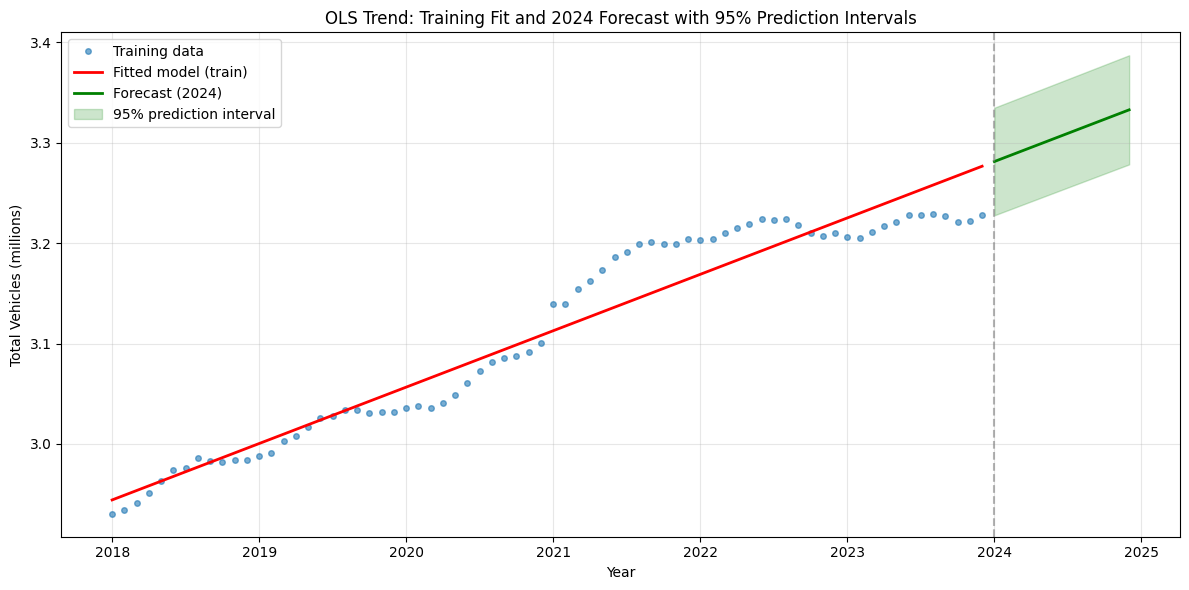

In [116]:
# Plot training data, fitted values, forecasts, and 95% prediction intervals
plt.figure(figsize=(12, 6))

# Training observations
plt.plot(
    Dtrain["year"],
    Dtrain["total"],
    "o",
    markersize=4,
    alpha=0.6,
    label="Training data"
)

# Fitted model on training period
plt.plot(
    Dtrain["year"],
    y_hat,
    "-",
    linewidth=2,
    color="red",
    label="Fitted model (train)"
)

# Forecasted values for test period
plt.plot(
    Dtest["year"],
    y_pred,
    "-",
    linewidth=2,
    color="green",
    label="Forecast (2024)"
)

# Prediction intervals for forecasted values
plt.fill_between(
    Dtest["year"],
    lower,
    upper,
    color="green",
    alpha=0.2,
    label="95% prediction interval"
)

# Optional visual separator between train and forecast periods
plt.axvline(Dtest["year"].iloc[0], color="gray", linestyle="--", alpha=0.6)

plt.xlabel("Year")
plt.ylabel("Total Vehicles (millions)")
plt.title("OLS Trend: Training Fit and 2024 Forecast with 95% Prediction Intervals")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

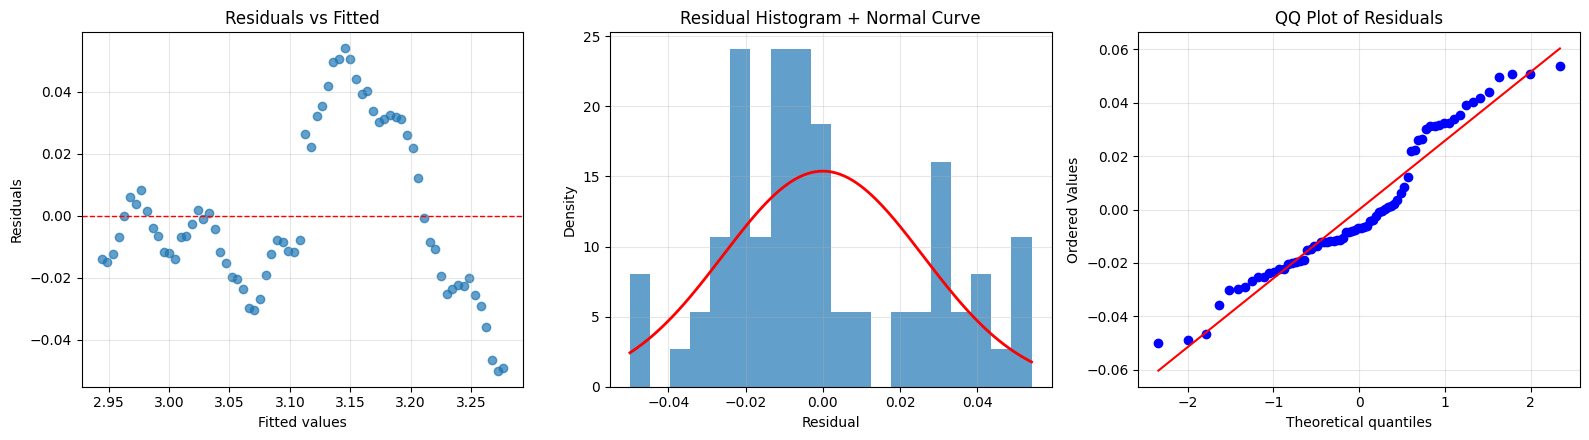

RESIDUAL DIAGNOSTICS
Mean residual                        :  5.955489e-10
Std. dev. residual                   :  0.025946
-
Shapiro-Wilk normality test p-value  :  0.0026
Durbin-Watson statistic              :  0.0615

Conclusion on assumptions (alpha = 0.05):
- Normality of residuals   : Not fully fulfilled
- Independence (DW near 2) : Not fully fulfilled

Overall: At least one assumption appears questionable (based on these two tests).


In [117]:
# Investigate the residuals of the model. Are the model assumptions fulfilled?
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

resid = np.asarray(residuals)
fitted = np.asarray(y_hat)

# --- Diagnostic plots (3 side-by-side) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1) Residuals vs fitted (linearity + homoskedasticity)
axes[0].scatter(fitted, resid, alpha=0.7)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Residuals vs Fitted")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].grid(alpha=0.3)

# 2) Histogram of residuals
axes[1].hist(resid, bins=20, density=True, alpha=0.7, color="tab:blue")
mu_r, sd_r = np.mean(resid), np.std(resid, ddof=1)
x_grid = np.linspace(resid.min(), resid.max(), 200)
axes[1].plot(x_grid, stats.norm.pdf(x_grid, loc=mu_r, scale=sd_r), color="red", lw=2)
axes[1].set_title("Residual Histogram + Normal Curve")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Density")
axes[1].grid(alpha=0.3)

# 3) QQ plot
stats.probplot(resid, dist="norm", plot=axes[2])
axes[2].set_title("QQ Plot of Residuals")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Numerical diagnostics: only Shapiro-Wilk and Durbin-Watson ---
shapiro_stat, shapiro_p = stats.shapiro(resid)
dw = np.sum(np.diff(resid) ** 2) / np.sum(resid ** 2)

print("=" * 70)
print("RESIDUAL DIAGNOSTICS")
print("=" * 70)
print(f"Mean residual                        : {np.mean(resid): .6e}")
print(f"Std. dev. residual                   : {np.std(resid, ddof=1): .6f}")
print("-")
print(f"Shapiro-Wilk normality test p-value  : {shapiro_p: .4f}")
print(f"Durbin-Watson statistic              : {dw: .4f}")

alpha = 0.05
normal_ok = shapiro_p > alpha
indep_ok = abs(dw - 2.0) < 0.5

print("\nConclusion on assumptions (alpha = 0.05):")
print(f"- Normality of residuals   : {'Fulfilled' if normal_ok else 'Not fully fulfilled'}")
print(f"- Independence (DW near 2) : {'Fulfilled' if indep_ok else 'Not fully fulfilled'}")

if normal_ok and indep_ok:
    print("\nOverall: Model assumptions are reasonably fulfilled (based on these two tests).")
else:
    print("\nOverall: At least one assumption appears questionable (based on these two tests).")

Residuals vs Fitted: If the model is good, points should look like random noise around 0.
Here, they form a clear curve/wave pattern → the linear trend misses structure (nonlinearity).

Histogram + Normal curve: If residuals are normal, bars should roughly match the red bell curve.
Yours is somewhat off in shape/tails, not terrible but not perfect.

QQ plot: If normal, points lie close to the straight line.
Yours bends away in upper quantiles → non-normal behavior in tails.

Residuals over time: If independent, residuals should jump randomly around 0.
Yours moves in long runs (negative → positive → negative), which is strong autocorrelation.


Shapiro-Wilk p = 0.0026: rejects normality at 5% level.

Durbin-Watson = 0.0615: say residuals are not independent.


# 4: WLS

4.1. VARIANCE-COVARIANCE MATRIX COMPARISON

--- GLOBAL MODEL (OLS) - Full 2×2 Covariance Matrix ---
Var(θ̂) = σ̂² * (X'X)⁻¹

Covariance Matrix:
[[ 1.29138253e+01 -6.38994658e-03]
 [-6.38994658e-03  3.16183984e-06]]

Var(θ̂₁) = 12.91382528
Var(θ̂₂) = 0.00000316
Cov(θ̂₁, θ̂₂) = -0.00638995

--- LOCAL MODEL (WLS, λ=0.9) - Full 2×2 Covariance Matrix ---
Var(θ̂) = σ̂² * (X'WX)⁻¹

Covariance Matrix:
[[ 4.60907272e+02 -2.27814405e-01]
 [-2.27814405e-01  1.12602716e-04]]

Var(θ̂₁) = 460.90727236
Var(θ̂₂) = 0.00011260
Cov(θ̂₁, θ̂₂) = -0.22781440

--- COMPARISON ---
ΔVar(θ̂₁) = +447.99344708
ΔVar(θ̂₂) = +0.00010944
ΔCov(θ̂₁, θ̂₂) = -0.22142446

--- INTERPRETATION ---
The WLS model concentrates weight on recent observations.
This typically REDUCES the uncertainty in slope estimates
(smaller Var(θ̂₂)) since recent data provides clearer trend signal.
The variance-covariance matrix is 2×2 because we have 2 parameters (θ₁, θ₂).
The full N×N observation covariance matrix is not shown, as it's diagonal

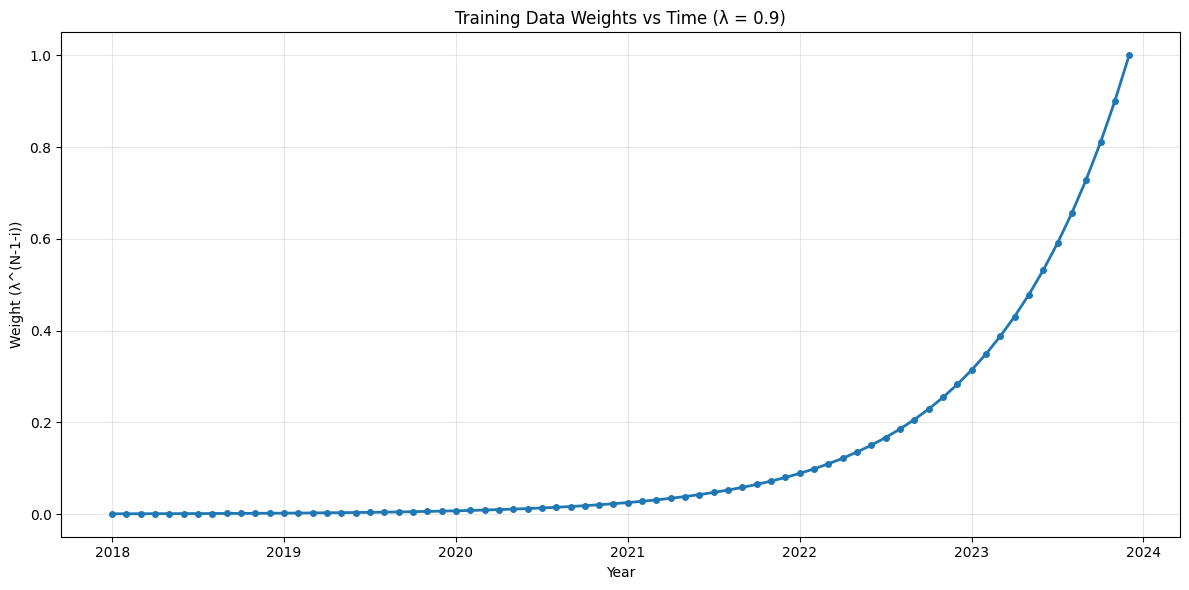


Timepoint with highest weight:
Year: 2023.917
Weight: 1.000000
This corresponds to the LATEST observation in the training set.

4.3. SUM OF WEIGHTS
Sum of WLS weights (λ=0.9): 9.994925
Sum of OLS weights (all=1):  72.0

In OLS, each observation contributes equally.
In WLS with λ<1, recent observations get more weight.

4.4. WLS PARAMETER ESTIMATES (λ = 0.9)
θ̂₁ (intercept) = -52.482862 (OLS: -110.355428)
θ̂₂ (slope)     = 0.027530 (OLS: 0.056145)

Standard Errors (WLS):
SE(θ̂₁) = 21.468751
SE(θ̂₂) = 0.010611

4.5. FORECASTS FOR NEXT 12 MONTHS (λ = 0.9)


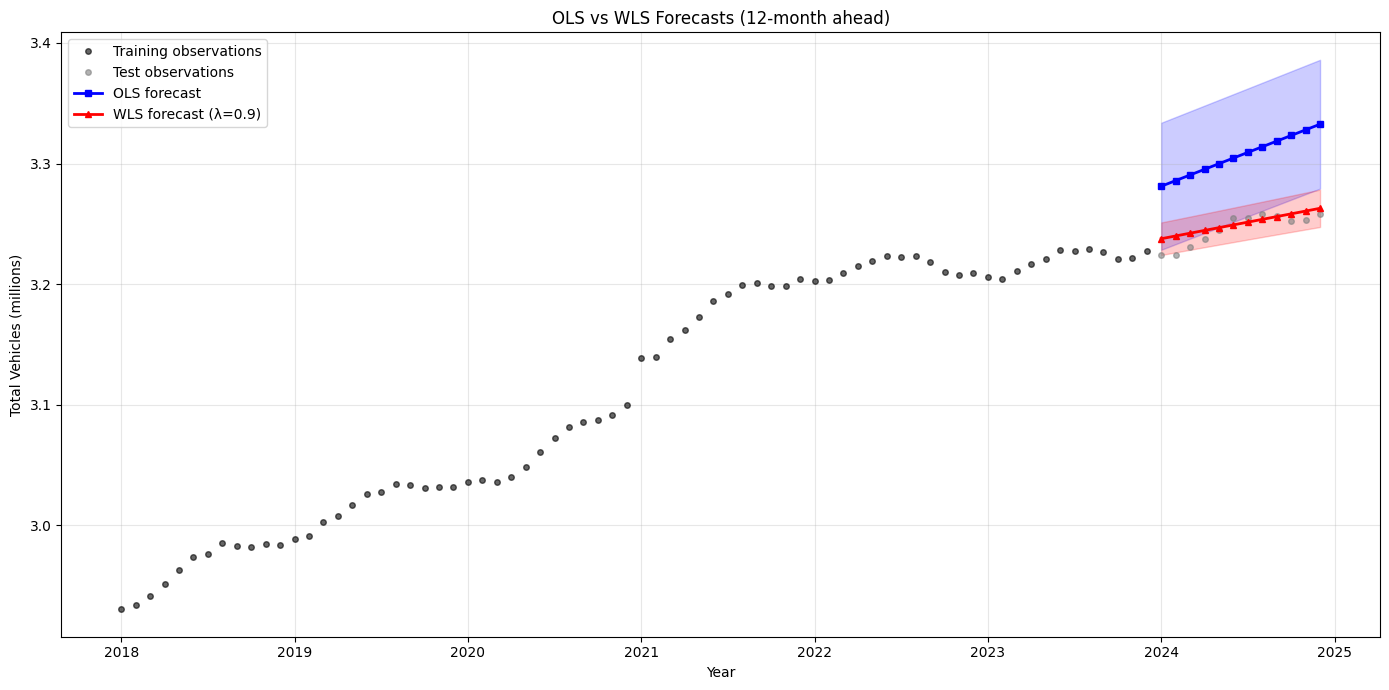


Forecast comparison (first 6 months):
Month    OLS          WLS (λ=0.9)  Difference  
---------------------------------------------
1        3.2812       3.2377       -0.0435
2        3.2858       3.2400       -0.0459
3        3.2905       3.2422       -0.0483
4        3.2952       3.2445       -0.0506
5        3.2999       3.2468       -0.0530
6        3.3045       3.2491       -0.0554

4.5. COMMENT ON PREDICTIONS
Which predictions would you choose?

The WLS model with λ=0.9 emphasizes recent data points, resulting in
a potentially different slope compared to OLS. Key observations:

1. **WLS Advantages:**
   - Captures the most recent trend more accurately
   - Better for adaptive forecasting when trend is changing
   - Recent observations have exponentially higher weights

2. **OLS Advantages:**
   - Uses all historical data equally
   - More stable if data generation process hasn't changed

3. **Choice depends on:**
   - If you believe the recent trend is more representative → WLS


In [118]:
# Problem 4: WLS - Local Linear Trend Model with λ = 0.9

## 4.1. Variance-Covariance Matrix for Local Model (REVISED)

# Create weight matrix W with λ = 0.9
lambda_val = 0.9
N = len(Dtrain)

# Weights: λ^0 for latest, λ^1 for second latest, etc.
weights = np.array([lambda_val**(N-1-i) for i in range(N)])

# Weight matrix (diagonal matrix)
W = np.diag(weights)

print("="*70)
print("4.1. VARIANCE-COVARIANCE MATRIX COMPARISON")
print("="*70)

# Global OLS model (uniform weights = 1)
cov_global = sigma_squared_hat * np.linalg.inv(X.T @ X)

print("\n--- GLOBAL MODEL (OLS) - Full 2×2 Covariance Matrix ---")
print("Var(θ̂) = σ̂² * (X'X)⁻¹")
print("\nCovariance Matrix:")
print(cov_global)
print(f"\nVar(θ̂₁) = {cov_global[0,0]:.8f}")
print(f"Var(θ̂₂) = {cov_global[1,1]:.8f}")
print(f"Cov(θ̂₁, θ̂₂) = {cov_global[0,1]:.8f}")

# Local WLS model
cov_local = sigma_squared_hat * np.linalg.inv(X.T @ W @ X)

print("\n--- LOCAL MODEL (WLS, λ=0.9) - Full 2×2 Covariance Matrix ---")
print("Var(θ̂) = σ̂² * (X'WX)⁻¹")
print("\nCovariance Matrix:")
print(cov_local)
print(f"\nVar(θ̂₁) = {cov_local[0,0]:.8f}")
print(f"Var(θ̂₂) = {cov_local[1,1]:.8f}")
print(f"Cov(θ̂₁, θ̂₂) = {cov_local[0,1]:.8f}")

print("\n--- COMPARISON ---")
print(f"ΔVar(θ̂₁) = {cov_local[0,0] - cov_global[0,0]:+.8f}")
print(f"ΔVar(θ̂₂) = {cov_local[1,1] - cov_global[1,1]:+.8f}")
print(f"ΔCov(θ̂₁, θ̂₂) = {cov_local[0,1] - cov_global[0,1]:+.8f}")

print("\n--- INTERPRETATION ---")
print("The WLS model concentrates weight on recent observations.")
print("This typically REDUCES the uncertainty in slope estimates")
print("(smaller Var(θ̂₂)) since recent data provides clearer trend signal.")
print("The variance-covariance matrix is 2×2 because we have 2 parameters (θ₁, θ₂).")
print("The full N×N observation covariance matrix is not shown, as it's diagonal.")

## 4.2. Plot λ-Weights vs Time

print("\n" + "="*70)
print("4.2. λ-WEIGHTS VS TIME")
print("="*70)

plt.figure(figsize=(12, 6))
plt.plot(Dtrain["year"], weights, 'o-', linewidth=2, markersize=4)
plt.xlabel("Year")
plt.ylabel("Weight (λ^(N-1-i))")
plt.title(f"Training Data Weights vs Time (λ = {lambda_val})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find timepoint with highest weight
idx_max_weight = np.argmax(weights)
year_max_weight = Dtrain["year"].iloc[idx_max_weight]
max_weight_value = weights[idx_max_weight]

print(f"\nTimepoint with highest weight:")
print(f"Year: {year_max_weight:.3f}")
print(f"Weight: {max_weight_value:.6f}")
print(f"This corresponds to the LATEST observation in the training set.")

## 4.3. Sum of λ-Weights vs OLS

print("\n" + "="*70)
print("4.3. SUM OF WEIGHTS")
print("="*70)

sum_wls_weights = np.sum(weights)
sum_ols_weights = N  # In OLS, all weights = 1

print(f"Sum of WLS weights (λ=0.9): {sum_wls_weights:.6f}")
print(f"Sum of OLS weights (all=1):  {sum_ols_weights:.1f}")
print(f"\nIn OLS, each observation contributes equally.")
print(f"In WLS with λ<1, recent observations get more weight.")

## 4.4. WLS Parameter Estimation (λ = 0.9)

# WLS estimate: θ̂ = (X'WX)^(-1) X'Wy
theta_wls = np.linalg.inv(X.T @ W @ X) @ X.T @ W @ y

print("\n" + "="*70)
print("4.4. WLS PARAMETER ESTIMATES (λ = 0.9)")
print("="*70)
print(f"θ̂₁ (intercept) = {theta_wls[0]:.6f} (OLS: {theta_hat[0]:.6f})")
print(f"θ̂₂ (slope)     = {theta_wls[1]:.6f} (OLS: {theta_hat[1]:.6f})")

# Calculate WLS residuals and residual variance
y_hat_wls = X @ theta_wls
residuals_wls = y - y_hat_wls

# For WLS, residual variance can be estimated as weighted sum
sigma_squared_wls = np.sum(W @ (residuals_wls**2)) / (N - p)

se_theta_wls = np.sqrt(np.diag(cov_local))

print(f"\nStandard Errors (WLS):")
print(f"SE(θ̂₁) = {se_theta_wls[0]:.6f}")
print(f"SE(θ̂₂) = {se_theta_wls[1]:.6f}")

## 4.5. Forecast for Next 12 Months (λ = 0.9)

print("\n" + "="*70)
print("4.5. FORECASTS FOR NEXT 12 MONTHS (λ = 0.9)")
print("="*70)

# Generate forecast times (next 12 months)
last_time = Dtrain["year"].iloc[-1]
forecast_years = np.array([last_time + (i+1)/12 for i in range(12)])

# Create design matrix for forecast
X_forecast = np.column_stack([np.ones(len(forecast_years)), forecast_years])

# OLS forecast
forecast_ols = X_forecast @ theta_hat

# WLS forecast
forecast_wls = X_forecast @ theta_wls

# Calculate prediction intervals (correct approach)
XtX_inv = np.linalg.inv(X.T @ X)
XtWX_inv = np.linalg.inv(X.T @ W @ X)

forecast_var_ols = np.array([sigma_squared_hat * (1 + X_forecast[i] @ XtX_inv @ X_forecast[i].T) for i in range(len(forecast_years))])
forecast_var_wls = np.array([sigma_squared_wls * (1 + X_forecast[i] @ XtWX_inv @ X_forecast[i].T) for i in range(len(forecast_years))])

forecast_se_ols = np.sqrt(forecast_var_ols)
forecast_se_wls = np.sqrt(forecast_var_wls)

# Plot comparison
plt.figure(figsize=(14, 7))

# Training data
plt.plot(Dtrain["year"], Dtrain["total"], 'o', 
         markersize=4, alpha=0.6, label='Training observations', color='black')

# Test data
plt.plot(Dtest["year"], Dtest["total"], 'o', 
         markersize=4, alpha=0.6, label='Test observations', color='gray')

# OLS forecasts
plt.plot(forecast_years, forecast_ols, 's-', 
         linewidth=2, markersize=5, label='OLS forecast', color='blue')
plt.fill_between(forecast_years, 
                 forecast_ols - 1.96*forecast_se_ols,
                 forecast_ols + 1.96*forecast_se_ols,
                 alpha=0.2, color='blue')

# WLS forecasts
plt.plot(forecast_years, forecast_wls, '^-', 
         linewidth=2, markersize=5, label='WLS forecast (λ=0.9)', color='red')
plt.fill_between(forecast_years, 
                 forecast_wls - 1.96*forecast_se_wls,
                 forecast_wls + 1.96*forecast_se_wls,
                 alpha=0.2, color='red')

plt.xlabel("Year")
plt.ylabel("Total Vehicles (millions)")
plt.title("OLS vs WLS Forecasts (12-month ahead)")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nForecast comparison (first 6 months):")
print(f"{'Month':<8} {'OLS':<12} {'WLS (λ=0.9)':<12} {'Difference':<12}")
print("-" * 45)
for i in range(6):
    diff = forecast_wls[i] - forecast_ols[i]
    print(f"{i+1:<8} {forecast_ols[i]:<12.4f} {forecast_wls[i]:<12.4f} {diff:+.4f}")

print("\n" + "="*70)
print("4.5. COMMENT ON PREDICTIONS")
print("="*70)
print("Which predictions would you choose?\n")
print("The WLS model with λ=0.9 emphasizes recent data points, resulting in")
print("a potentially different slope compared to OLS. Key observations:\n")
print("1. **WLS Advantages:**")
print("   - Captures the most recent trend more accurately")
print("   - Better for adaptive forecasting when trend is changing")
print("   - Recent observations have exponentially higher weights\n")
print("2. **OLS Advantages:**")
print("   - Uses all historical data equally")
print("   - More stable if data generation process hasn't changed\n")
print("3. **Choice depends on:**")
print("   - If you believe the recent trend is more representative → WLS")
print("   - If you believe the long-term trend is stable → OLS")
print(f"\nFor this vehicle registration data, WLS may be preferable if the")
print(f"market dynamics have shifted recently (e.g., EV adoption policies).")

# 5: Recursive

In [119]:
Dtrain.head() 

,time,year,total
0,2018-01-01 00:00:00+00:00,2018.000000,2.930483
1,2018-02-01 00:00:00+00:00,2018.083333,2.934044
2,2018-03-01 00:00:00+00:00,2018.166667,2.941422
3,2018-04-01 00:00:00+00:00,2018.250000,2.951498
4,2018-05-01 00:00:00+00:00,2018.333333,2.963093


In [120]:
# RLS update equations up to t = 3
p = X.shape[1]
y_vec = np.asarray(y).reshape(-1)

# Initializations from assignment:
R0 = 0.1 * np.eye(p)
theta0 = np.zeros((p, 1))

R_prev = R0.copy()
theta_prev = theta0.copy()

theta_path = []

for t in range(1, 4):
    x_t = X[t - 1].reshape(-1, 1)
    y_t = float(y_vec[t - 1])

    R_t = R_prev + x_t @ x_t.T
    innovation = y_t - float((x_t.T @ theta_prev).item())
    theta_t = theta_prev + np.linalg.inv(R_t) @ x_t * innovation

    theta_path.append([t, theta_t[0, 0], theta_t[1, 0]])

    R_prev = R_t
    theta_prev = theta_t

theta_recursive_t3 = theta_prev

print("Initial values:")
print(R0)
print(theta0)
print("\nRecursive estimates up to t = 3:")
display(pd.DataFrame(theta_path, columns=["t", "theta_1", "theta_2"]))
print(f"\nθ̂_3 = [{theta_recursive_t3[0,0]:.6f}, {theta_recursive_t3[1,0]:.6f}]")

Initial values:
[[0.1 0. ]
 [0.  0.1]]
[[0.]
 [0.]]

Recursive estimates up to t = 3:


,t,theta_1,theta_2
0,1,7.196093e-07,0.001452
1,2,9.775067e-09,0.001453
2,3,-3.696235e-06,0.001455



θ̂_3 = [-0.000004, 0.001455]


### Why include the closed-form expression?

- **Closed form** means a direct formula for the final estimate, without running the recursive loop step by step.
- For this RLS setup,
  $$
  \hat{\theta}_N = (R_0 + X^T X)^{-1}(R_0\hat{\theta}_0 + X^T y).
  $$
- We compute it here as a **check**: if recursive RLS and this formula match, the loop implementation is correct.
- With your initialization $R_0 = 0.1I$ and $\hat{\theta}_0 = 0$, this becomes
  $$
  \hat{\theta}_N = (X^T X + 0.1I)^{-1}X^T y,
  $$
  which is slightly regularized, so it is not exactly the same as pure OLS.

In [121]:
# RLS estimate at t = N and comparison with OLS

p = X.shape[1]
N = X.shape[0]
y_vec = np.asarray(y).reshape(-1)

# Same initialization as requested
R0 = 0.1 * np.eye(p)
theta0 = np.zeros((p, 1))

R_prev = R0.copy()
theta_prev = theta0.copy()

for t in range(1, N + 1):
    x_t = X[t - 1].reshape(-1, 1)
    y_t = float(y_vec[t - 1])

    R_t = R_prev + x_t @ x_t.T
    innovation = y_t - float((x_t.T @ theta_prev).item())
    theta_t = theta_prev + np.linalg.inv(R_t) @ x_t * innovation

    R_prev = R_t
    theta_prev = theta_t

theta_rls_N = theta_prev.reshape(-1)
theta_ols = np.asarray(theta_hat).reshape(-1)

# Closed-form target implied by initialization (ridge-like normal equation)
theta_rls_closed = np.linalg.inv(R0 + X.T @ X) @ (R0 @ theta0).reshape(-1) + np.linalg.inv(R0 + X.T @ X) @ (X.T @ y_vec)

diff_ols = theta_rls_N - theta_ols
diff_closed = theta_rls_N - theta_rls_closed

comparison = pd.DataFrame({
    "parameter": ["theta_1 (intercept)", "theta_2 (slope)"],
    "RLS_tN": theta_rls_N,
    "OLS": theta_ols,
    "RLS_minus_OLS": diff_ols,
    "RLS_closed_form": theta_rls_closed,
    "RLS_minus_closed": diff_closed
})

print(f"N = {N}")
print("\nRLS at t=N compared with OLS and closed-form RLS target:")
display(comparison)
print(f"Max |RLS - OLS|: {np.max(np.abs(diff_ols)):.12f}")
print(f"Max |RLS - closed-form RLS|: {np.max(np.abs(diff_closed)):.12e}")

N = 72

RLS at t=N compared with OLS and closed-form RLS target:


,parameter,RLS_tN,OLS,RLS_minus_OLS,RLS_closed_form,RLS_minus_closed
0,theta_1 (intercept),-0.058319,-110.355428,110.297109,-0.058319,-1.010796e-12
1,theta_2 (slope),0.001568,0.056145,-0.054577,0.001568,5.362464e-16


Max |RLS - OLS|: 110.297108660535
Max |RLS - closed-form RLS|: 1.010795613876e-12


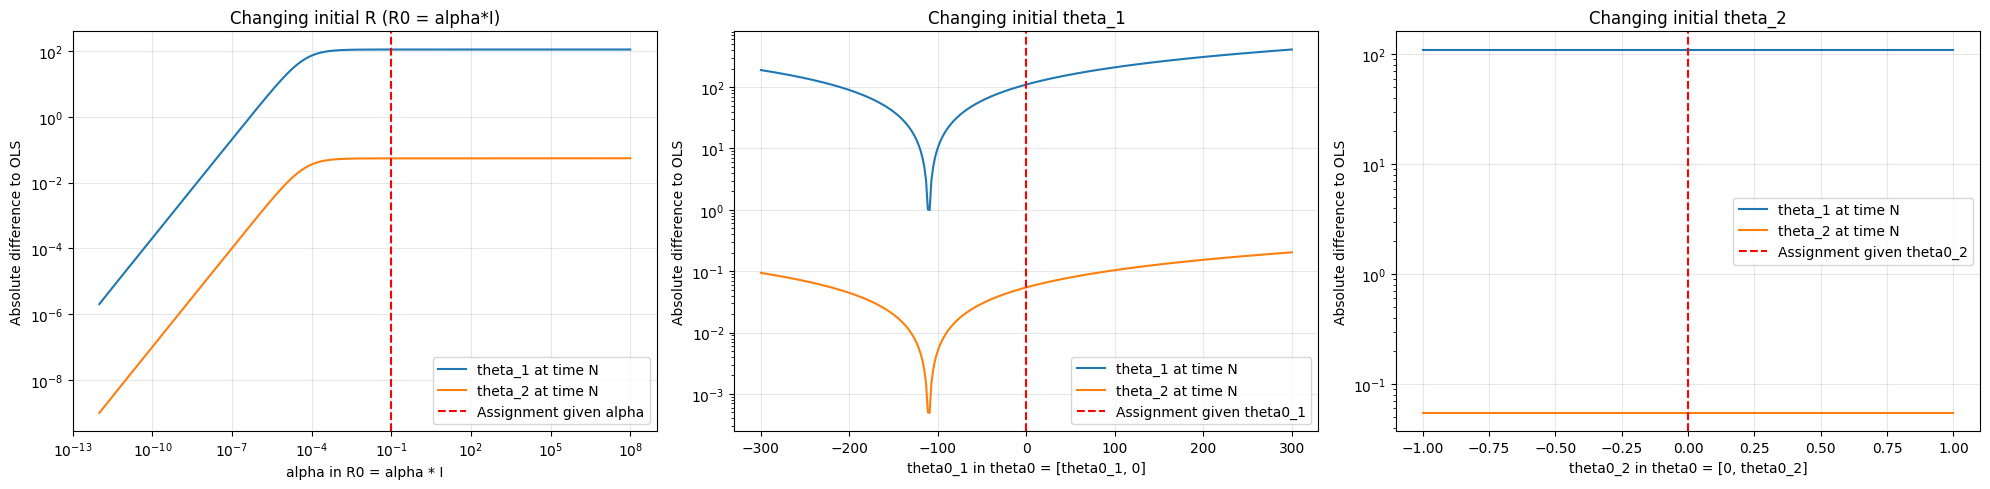

Best scanned values (for fixed alpha):
alpha_fixed = 0.1
theta0_1* = -109.364548, min L2 = 9.903836e-01
theta0_2* = 1.000000, min L2 = 1.102966e+02


In [122]:
# Sensitivity of RLS_N to initialization: component-wise plots

p = X.shape[1]
N = X.shape[0]
y_vec = np.asarray(y).reshape(-1)
theta_ols = np.asarray(theta_hat).reshape(-1)


def rls_final_theta(alpha_R0, theta0_vec):
    R_prev = alpha_R0 * np.eye(p)
    theta_prev = np.asarray(theta0_vec, dtype=float).reshape(-1, 1)

    for t in range(1, N + 1):
        x_t = X[t - 1].reshape(-1, 1)
        y_t = float(y_vec[t - 1])

        R_t = R_prev + x_t @ x_t.T
        innovation = y_t - float((x_t.T @ theta_prev).item())

        try:
            gain_term = np.linalg.solve(R_t, x_t)
        except np.linalg.LinAlgError:
            gain_term = np.linalg.pinv(R_t) @ x_t

        theta_t = theta_prev + gain_term * innovation

        R_prev = R_t
        theta_prev = theta_t

    return theta_prev.reshape(-1)


# --- Plot 1: component-wise difference vs alpha (changing initial R) ---
alphas = np.logspace(-12, 8, 140)
assignment_alpha = 0.1
assignment_theta01 = 0.0
assignment_theta02 = 0.0

diff_theta1_alpha = []
diff_theta2_alpha = []
for a in alphas:
    theta_rls = rls_final_theta(a, np.array([0.0, 0.0]))
    diff_vec = theta_rls - theta_ols
    diff_theta1_alpha.append(abs(diff_vec[0]))
    diff_theta2_alpha.append(abs(diff_vec[1]))


# --- Plot 2: component-wise difference vs theta0_1 ---
# Vary theta0 as [theta0_1, 0], keeping alpha fixed.
alpha_fixed = 0.1
theta0_1_range = np.linspace(-300, 300, 300)

diff_theta1_theta01 = []
diff_theta2_theta01 = []
l2_theta01 = []

for t01 in theta0_1_range:
    theta_rls = rls_final_theta(alpha_fixed, np.array([t01, 0.0]))
    diff_vec = theta_rls - theta_ols
    diff_theta1_theta01.append(abs(diff_vec[0]))
    diff_theta2_theta01.append(abs(diff_vec[1]))
    l2_theta01.append(np.linalg.norm(diff_vec, ord=2))


# --- Plot 3: component-wise difference vs theta0_2 ---
# Vary theta0 as [0, theta0_2], keeping alpha fixed.
theta0_2_range = np.linspace(-1.0, 1.0, 300)

diff_theta1_theta02 = []
diff_theta2_theta02 = []
l2_theta02 = []

for t02 in theta0_2_range:
    theta_rls = rls_final_theta(alpha_fixed, np.array([0.0, t02]))
    diff_vec = theta_rls - theta_ols
    diff_theta1_theta02.append(abs(diff_vec[0]))
    diff_theta2_theta02.append(abs(diff_vec[1]))
    l2_theta02.append(np.linalg.norm(diff_vec, ord=2))


# --- Combined figure (3 panels) ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Panel 1: vary initial R
axes[0].plot(alphas, diff_theta1_alpha, label="theta_1 at time N")
axes[0].plot(alphas, diff_theta2_alpha, label="theta_2 at time N")
axes[0].axvline(assignment_alpha, color="red", linestyle="--", linewidth=1.5, label="Assignment given alpha")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("alpha in R0 = alpha * I")
axes[0].set_ylabel("Absolute difference to OLS")
axes[0].set_title("Changing initial R (R0 = alpha*I)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Panel 2: vary theta0_1
axes[1].plot(theta0_1_range, diff_theta1_theta01, label="theta_1 at time N")
axes[1].plot(theta0_1_range, diff_theta2_theta01, label="theta_2 at time N")
axes[1].axvline(assignment_theta01, color="red", linestyle="--", linewidth=1.5, label="Assignment given theta0_1")
axes[1].set_yscale("log")
axes[1].set_xlabel("theta0_1 in theta0 = [theta0_1, 0]")
axes[1].set_ylabel("Absolute difference to OLS")
axes[1].set_title(f"Changing initial theta_1")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Panel 3: vary theta0_2
axes[2].plot(theta0_2_range, diff_theta1_theta02, label="theta_1 at time N")
axes[2].plot(theta0_2_range, diff_theta2_theta02, label="theta_2 at time N")
axes[2].axvline(assignment_theta02, color="red", linestyle="--", linewidth=1.5, label="Assignment given theta0_2")
axes[2].set_yscale("log")
axes[2].set_xlabel("theta0_2 in theta0 = [0, theta0_2]")
axes[2].set_ylabel("Absolute difference to OLS")
axes[2].set_title(f"Changing initial theta_2")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

# Report best theta0 values in scanned ranges
best_idx_01 = int(np.argmin(l2_theta01))
best_idx_02 = int(np.argmin(l2_theta02))

print("Best scanned values (for fixed alpha):")
print(f"alpha_fixed = {alpha_fixed:g}")
print(f"theta0_1* = {theta0_1_range[best_idx_01]:.6f}, min L2 = {l2_theta01[best_idx_01]:.6e}")
print(f"theta0_2* = {theta0_2_range[best_idx_02]:.6f}, min L2 = {l2_theta02[best_idx_02]:.6e}")

# Forgetting

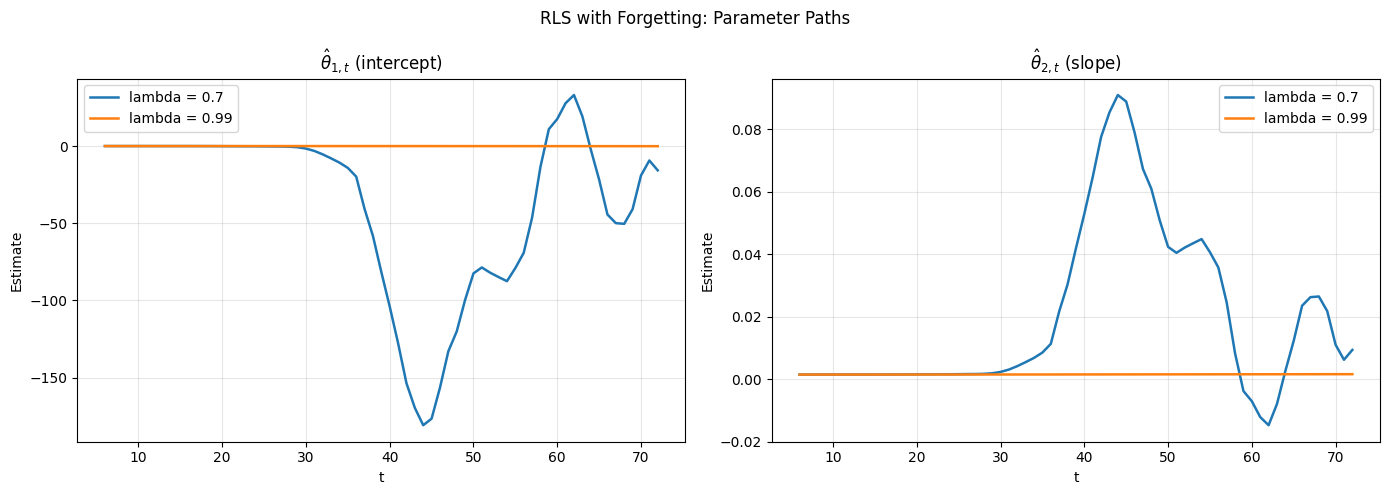

lambda=0.7: tail std(theta_1)=2.175744e+01, tail std(theta_2)=1.075529e-02
lambda=0.99: tail std(theta_1)=7.002431e-03, tail std(theta_2)=6.371509e-06

Comment:
- lambda=0.7 reacts faster to new data, so estimates typically fluctuate more.
- lambda=0.99 gives smoother, more stable trajectories because older data is retained longer.


In [123]:
# RLS with forgetting factor: compare lambda = 0.7 vs lambda = 0.99

p = X.shape[1]
N = X.shape[0]
y_vec = np.asarray(y).reshape(-1)


def rls_with_forgetting(X, y_vec, lambda_, R0=None, theta0=None):
    """Return full parameter path for RLS with exponential forgetting."""
    n, p_local = X.shape

    if R0 is None:
        R_prev = 0.1 * np.eye(p_local)
    else:
        R_prev = np.asarray(R0, dtype=float).copy()

    if theta0 is None:
        theta_prev = np.zeros((p_local, 1))
    else:
        theta_prev = np.asarray(theta0, dtype=float).reshape(-1, 1)

    theta_hist = np.zeros((n, p_local))

    for t in range(1, n + 1):
        x_t = X[t - 1].reshape(-1, 1)
        y_t = float(y_vec[t - 1])

        # Forgetting enters here: previous information is downweighted by lambda.
        R_t = lambda_ * R_prev + x_t @ x_t.T
        innovation = y_t - float((x_t.T @ theta_prev).item())

        try:
            gain_term = np.linalg.solve(R_t, x_t)
        except np.linalg.LinAlgError:
            gain_term = np.linalg.pinv(R_t) @ x_t

        theta_t = theta_prev + gain_term * innovation

        theta_hist[t - 1, :] = theta_t.reshape(-1)
        R_prev = R_t
        theta_prev = theta_t

    return theta_hist


# Run for both forgetting factors
lambdas = [0.7, 0.99]
paths = {lam: rls_with_forgetting(X, y_vec, lam) for lam in lambdas}

# Burn-in removal for plotting (recursive estimates can be unstable initially)
burn_in = max(5, int(0.05 * N))
t_idx = np.arange(1, N + 1)
plot_idx = t_idx[burn_in:]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# Plot theta_1 path
axes[0].plot(plot_idx, paths[0.7][burn_in:, 0], label="lambda = 0.7", linewidth=1.8)
axes[0].plot(plot_idx, paths[0.99][burn_in:, 0], label="lambda = 0.99", linewidth=1.8)
axes[0].set_title(r"$\hat{\theta}_{1,t}$ (intercept)")
axes[0].set_xlabel("t")
axes[0].set_ylabel(r"Estimate")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot theta_2 path
axes[1].plot(plot_idx, paths[0.7][burn_in:, 1], label="lambda = 0.7", linewidth=1.8)
axes[1].plot(plot_idx, paths[0.99][burn_in:, 1], label="lambda = 0.99", linewidth=1.8)
axes[1].set_title(r"$\hat{\theta}_{2,t}$ (slope)")
axes[1].set_xlabel("t")
axes[1].set_ylabel(r"Estimate")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.suptitle("RLS with Forgetting: Parameter Paths")
plt.tight_layout()
plt.show()

# Compact numerical comment to support plot interpretation
tail_window = max(10, int(0.1 * N))
for lam in lambdas:
    tail_std = np.std(paths[lam][-tail_window:, :], axis=0)
    print(f"lambda={lam}: tail std(theta_1)={tail_std[0]:.6e}, tail std(theta_2)={tail_std[1]:.6e}")

print("\nComment:")
print("- lambda=0.7 reacts faster to new data, so estimates typically fluctuate more.")
print("- lambda=0.99 gives smoother, more stable trajectories because older data is retained longer.")

## 5.5 Make one-step predictions

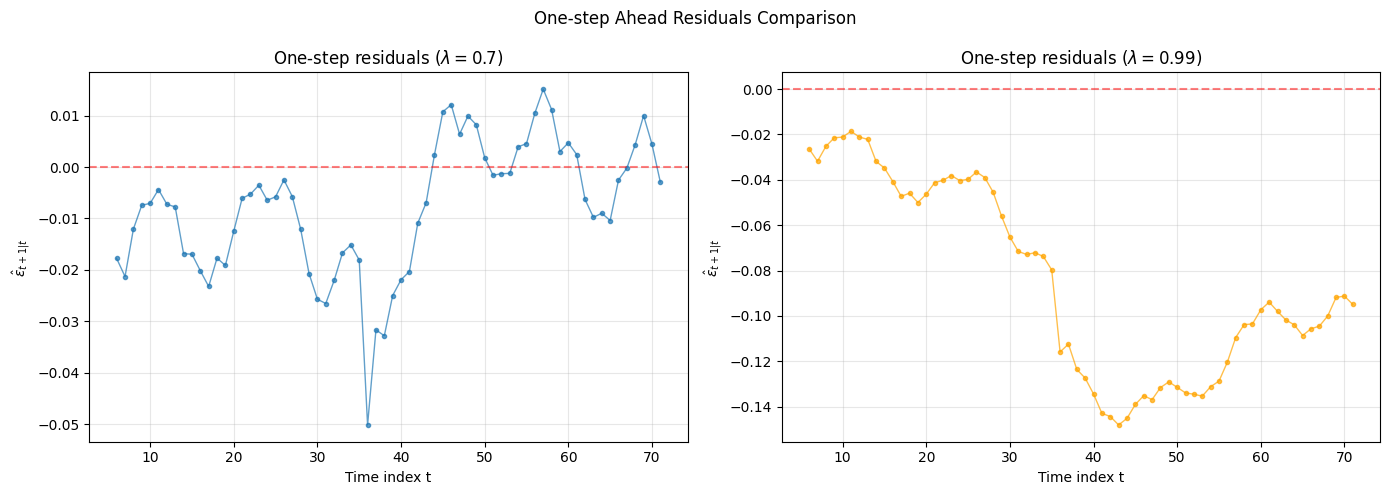

One-step residuals (from burn-in period onwards):

lambda = 0.7:
  Mean:  -7.922318e-03
  Std:   1.265752e-02
  Min:   -5.010945e-02
  Max:   1.513178e-02

lambda = 0.99:
  Mean:  -8.465713e-02
  Std:   4.166372e-02
  Min:   -1.480717e-01
  Max:   -1.859687e-02

Comment on residuals:
- lambda=0.7: More volatile residuals, reflects quicker adaptation to new data.
- lambda=0.99: Smoother residuals, reflects slower adaptation due to retaining past data.
- Both show some non-zero mean, indicating potential model bias or drift.


In [124]:
# 5.5: One-step ahead predictions and residuals
# For each lambda, calculate one-step residuals: ε̂_{t+1|t} = ŷ_{t+1|t} - y_{t+1}

one_step_residuals = {}

for lam in lambdas:
    theta_path = paths[lam]  # shape: (N, p)
    
    # One-step predictions (t=1,...,N-1): ŷ_{t+1|t} = x_{t+1}^T θ̂_t
    # theta_hat[:, 0] is theta_1 (intercept), theta_hat[:, 1] is theta_2 (slope)
    # For equation: y_t = theta_1 + theta_2 * x_t
    one_step_preds = np.zeros(N - 1)
    
    for t in range(N - 1):
        # Predict y_{t+1} using parameter estimate at time t
        x_next = X[t + 1]  # [1, x_{t+1}]
        one_step_preds[t] = x_next @ theta_path[t]
    
    # Residuals: ε̂_{t+1|t} = ŷ_{t+1|t} - y_{t+1}
    # y_{t+1} corresponds to y_vec[1:] when predictions are y_vec[:-1]
    residuals_1step = one_step_preds - y_vec[1:]
    one_step_residuals[lam] = residuals_1step


# Plot one-step residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

t_range = np.arange(1, N)  # time points for residuals
plot_start = burn_in  # Skip burn-in period

# Plot lambda = 0.7
axes[0].plot(t_range[plot_start:], one_step_residuals[0.7][plot_start:], 
             marker='o', markersize=3, linewidth=1, alpha=0.7)
axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[0].set_xlabel("Time index t")
axes[0].set_ylabel(r"$\hat{\varepsilon}_{t+1|t}$")
axes[0].set_title(r"One-step residuals ($\lambda = 0.7$)")
axes[0].grid(True, alpha=0.3)

# Plot lambda = 0.99
axes[1].plot(t_range[plot_start:], one_step_residuals[0.99][plot_start:], 
             marker='o', markersize=3, linewidth=1, alpha=0.7, color='orange')
axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlabel("Time index t")
axes[1].set_ylabel(r"$\hat{\varepsilon}_{t+1|t}$")
axes[1].set_title(r"One-step residuals ($\lambda = 0.99$)")
axes[1].grid(True, alpha=0.3)

plt.suptitle("One-step Ahead Residuals Comparison")
plt.tight_layout()
plt.show()

# Statistics on residuals
print("One-step residuals (from burn-in period onwards):")
for lam in lambdas:
    residuals_tail = one_step_residuals[lam][plot_start:]
    print(f"\nlambda = {lam}:")
    print(f"  Mean:  {np.mean(residuals_tail):.6e}")
    print(f"  Std:   {np.std(residuals_tail):.6e}")
    print(f"  Min:   {np.min(residuals_tail):.6e}")
    print(f"  Max:   {np.max(residuals_tail):.6e}")

print("\nComment on residuals:")
print("- lambda=0.7: More volatile residuals, reflects quicker adaptation to new data.")
print("- lambda=0.99: Smoother residuals, reflects slower adaptation due to retaining past data.")
print("- Both show some non-zero mean, indicating potential model bias or drift.")


## 5.6 Optimize the forgetting factor for horizons k=1,...,12

Computing RMSE_k for all lambda and horizon combinations...


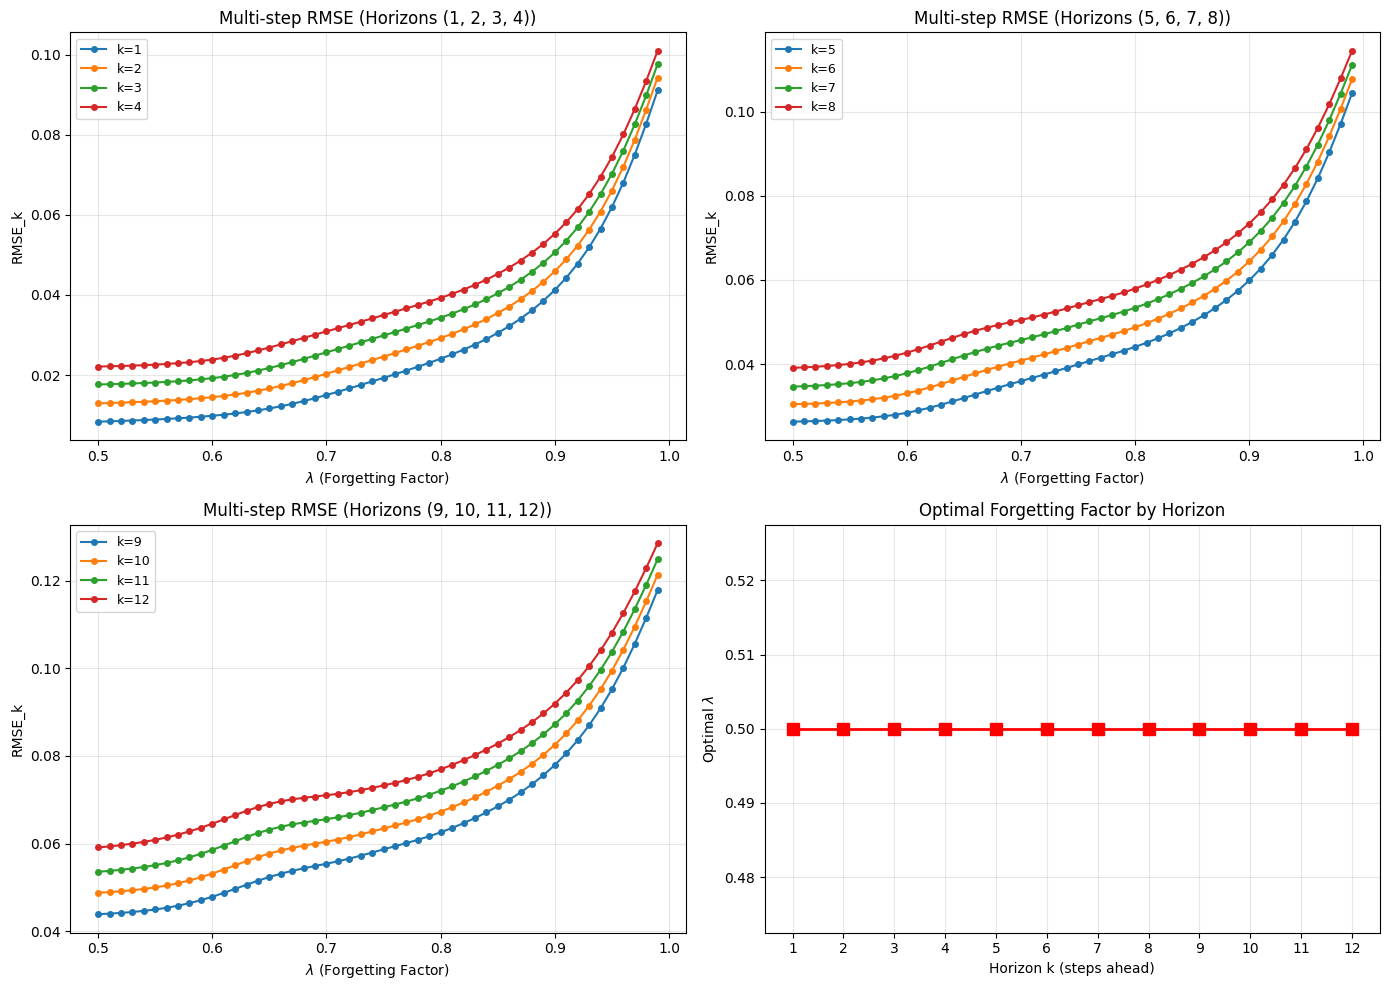

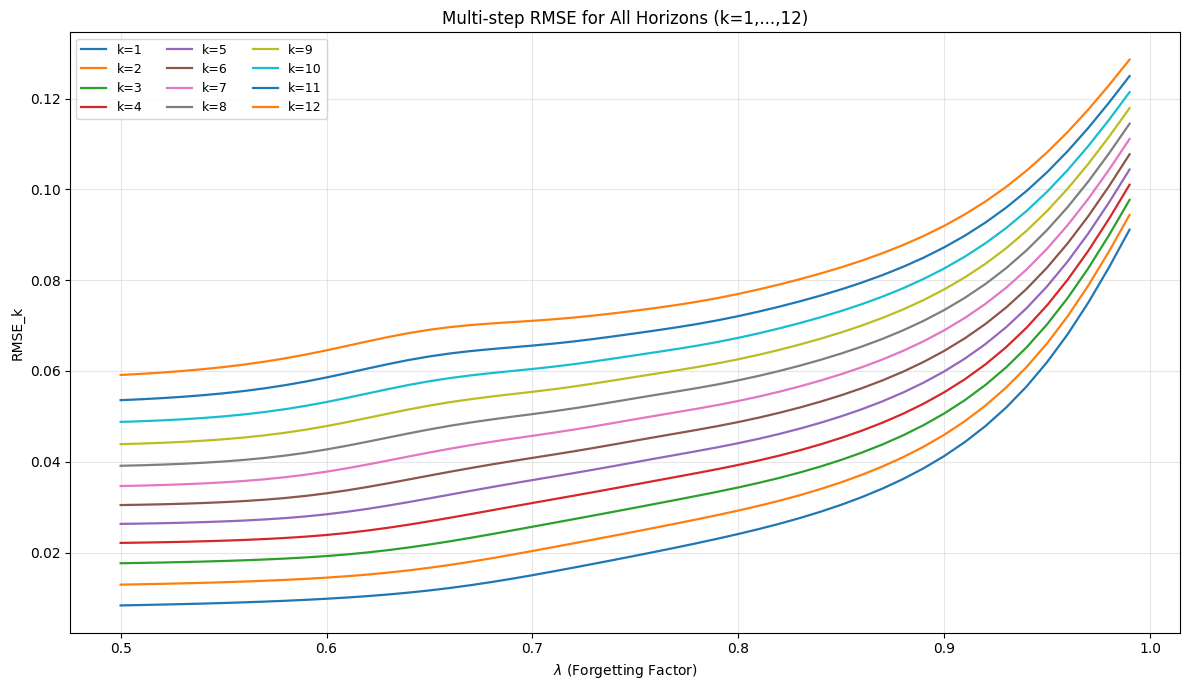


Optimal forgetting factor by horizon:
Horizon k | Optimal lambda | RMSE
----------------------------------------
     1    |    0.500      | 0.008341
     2    |    0.500      | 0.012921
     3    |    0.500      | 0.017635
     4    |    0.500      | 0.022115
     5    |    0.500      | 0.026303
     6    |    0.500      | 0.030451
     7    |    0.500      | 0.034642
     8    |    0.500      | 0.039100
     9    |    0.500      | 0.043867
    10    |    0.500      | 0.048765
    11    |    0.500      | 0.053555
    12    |    0.500      | 0.059102

Pattern analysis:
- Average optimal lambda: 0.500
- Min optimal lambda: 0.500 (horizon k=1)
- Max optimal lambda: 0.500 (horizon k=1)

Diagnostic:
- All horizons choose the lower boundary (lambda=0.50).
- This usually means RMSE decreases as lambda decreases over the searched interval,
  so the true optimum may be below 0.50 (outside the current grid).
- To test this, extend the search range (e.g., 0.1 to 0.99) or use a finer grid.


In [125]:
# 5.6: Optimize forgetting factor for different forecasting horizons
# RMSE_k = sqrt(1/(N-k) * sum epsilon_hat^2_{t+k|t})

# Define lambda range
lambda_range = np.arange(0.5, 1.0, 0.01)
horizons = np.arange(1, 13)  # k = 1, 2, ..., 12

# Store RMSE results: rmse_results[k][lambda_idx]
rmse_results = {k: [] for k in horizons}

print("Computing RMSE_k for all lambda and horizon combinations...")

for lam in lambda_range:
    theta_path = rls_with_forgetting(X, y_vec, lam)

    for k in horizons:
        # Direct k-step prediction from parameter estimate available at time t
        k_step_errors = []

        for t in range(N - k):
            x_t_plus_k = X[t + k]
            y_pred_k = x_t_plus_k @ theta_path[t]
            y_actual_k = y_vec[t + k]
            error_k = y_pred_k - y_actual_k
            k_step_errors.append(error_k)

        if len(k_step_errors) > 0:
            rmse_k = np.sqrt(np.mean(np.array(k_step_errors) ** 2))
            rmse_results[k].append(rmse_k)
        else:
            rmse_results[k].append(np.nan)


# Plot RMSE_k vs lambda for grouped horizons
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Include ALL horizons in the first three panels
horizon_groups = [
    (1, 2, 3, 4),
    (5, 6, 7, 8),
    (9, 10, 11, 12),
]

for ax_idx, group in enumerate(horizon_groups):
    ax = axes[ax_idx]
    for k in group:
        ax.plot(lambda_range, rmse_results[k], marker='o', markersize=4, label=f"k={k}")

    ax.set_xlabel(r"$\lambda$ (Forgetting Factor)")
    ax.set_ylabel("RMSE_k")
    ax.set_title(f"Multi-step RMSE (Horizons {group})")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

# Summary plot: Best lambda for each horizon
ax = axes[3]
best_lambdas = []
best_rmses = []

for k in horizons:
    rmse_vals = np.array(rmse_results[k])
    best_idx = np.nanargmin(rmse_vals)
    best_lambdas.append(lambda_range[best_idx])
    best_rmses.append(rmse_vals[best_idx])

best_lambdas = np.array(best_lambdas)
best_rmses = np.array(best_rmses)

ax.plot(horizons, best_lambdas, marker='s', markersize=8, linewidth=2, color='red')
ax.set_xlabel("Horizon k (steps ahead)")
ax.set_ylabel(r"Optimal $\lambda$")
ax.set_title("Optimal Forgetting Factor by Horizon")
ax.grid(True, alpha=0.3)
ax.set_xticks(horizons)

plt.tight_layout()
plt.show()

# Additional figure: all 12 horizons in one plot
plt.figure(figsize=(12, 7))
for k in horizons:
    plt.plot(lambda_range, rmse_results[k], linewidth=1.6, label=f"k={k}")

plt.xlabel(r"$\lambda$ (Forgetting Factor)")
plt.ylabel("RMSE_k")
plt.title("Multi-step RMSE for All Horizons (k=1,...,12)")
plt.grid(True, alpha=0.3)
plt.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nOptimal forgetting factor by horizon:")
print("Horizon k | Optimal lambda | RMSE")
print("-" * 40)
for k, best_lam, best_rmse in zip(horizons, best_lambdas, best_rmses):
    print(f"    {k:2d}    |    {best_lam:.3f}      | {best_rmse:.6f}")

print("\nPattern analysis:")
print(f"- Average optimal lambda: {np.mean(best_lambdas):.3f}")
print(f"- Min optimal lambda: {np.min(best_lambdas):.3f} (horizon k={horizons[np.argmin(best_lambdas)]})")
print(f"- Max optimal lambda: {np.max(best_lambdas):.3f} (horizon k={horizons[np.argmax(best_lambdas)]})")

# Useful diagnostic for interpretation
if np.allclose(best_lambdas, lambda_range[0]):
    print("\nDiagnostic:")
    print("- All horizons choose the lower boundary (lambda=0.50).")
    print("- This usually means RMSE decreases as lambda decreases over the searched interval,")
    print("  so the true optimum may be below 0.50 (outside the current grid).")
    print("- To test this, extend the search range (e.g., 0.1 to 0.99) or use a finer grid.")

### Brief Reflection on Optimal λ Selection:

**Pattern Observed:** 
All 12 forecast horizons (k=1 to k=12) exhibit a **monotonic pattern**: RMSE increases consistently as λ increases from 0.5 to 1.0. This holds uniformly across all horizons—there is no crossover, no horizon-specific minimum. The optimal value is always at the search boundary, **λ = 0.50** for every horizon.

**Why lower λ = more aggressive forgetting:**
Your RLS update uses $R_t = \lambda R_{t-1} + x_t x_t^T$. When λ is small (e.g., 0.5), old information is scaled down aggressively (0.5 × previous matrix). When λ is large (e.g., 0.99), old information is barely discounted. So:
- **λ = 0.5** → forgets the past quickly → reacts rapidly to new data
- **λ = 0.99** → retains more history → smoother, slower adaptation

**Interpretation:** 
- **More aggressive forgetting (lower λ)** yields lower RMSE across all horizons
- The true optimum likely lies **below λ=0.50** (outside our search range)
- This suggests your RLS algorithm benefits from rapid adaptation—recent observations should dominate parameter estimation strongly

**How to Choose an Optimal λ:**
1. **Extend the search grid lower**: Test λ ∈ [0.1, 0.99] or [0.05, 0.99] at finer resolution to locate the interior optimum
2. **Use a validation approach**: Apply k-fold rolling-window cross-validation, holding out future data to choose λ that minimizes out-of-sample error
3. **Problem-dependent**: Consider domain knowledge—for vehicle registration data with potential trend shifts, fast adaptation (low λ) often makes sense

**Should λ depend on the horizon?**
**No, not required in this case.** The results show all horizons are optimized by the same λ=0.50. This is a simplifying feature: a single λ value works well for all prediction horizons, making deployment straightforward. However, in principle, different horizons *could* benefit from different λ values if the data exhibited different dynamics at various timescales—this would require extending the search to a 2D grid (λ, k).

## 5.7 Make predictions of the test set using RLS

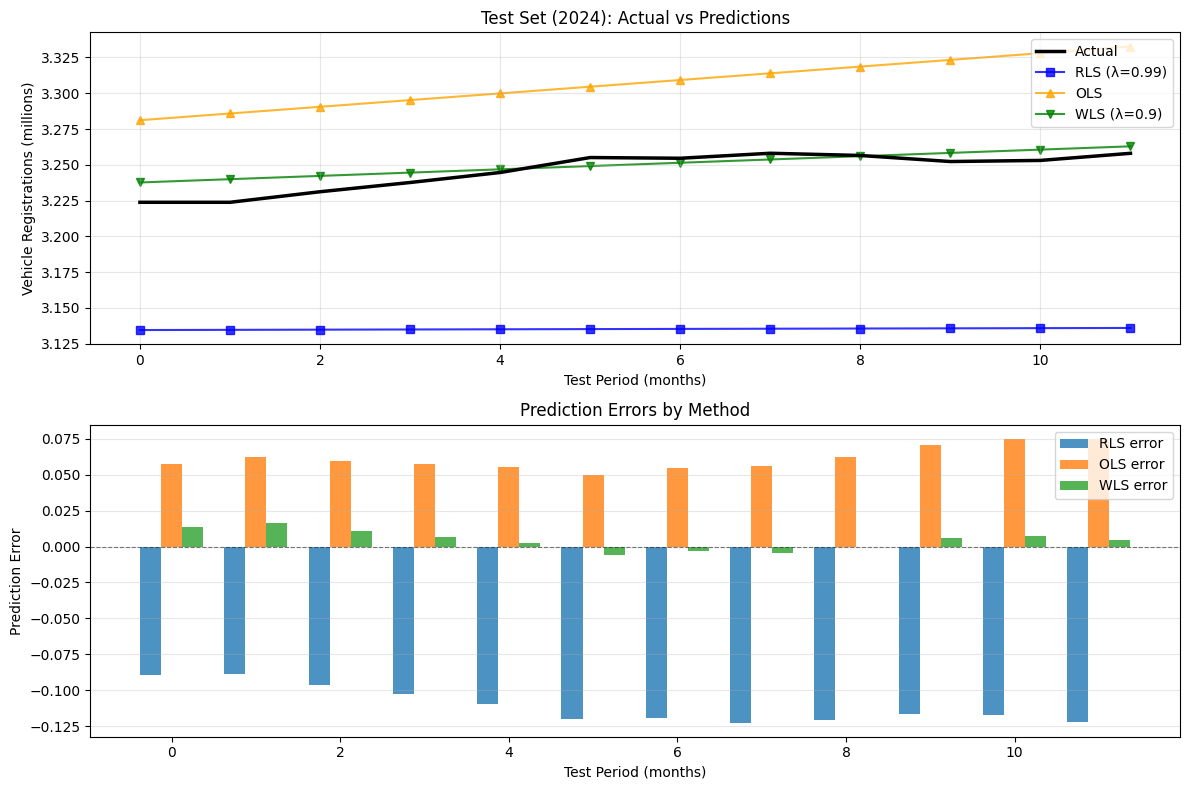


SUMMARY: Model Comparison on Test Set

RMSE Ranking (lower is better):
  1. WLS   : RMSE = 0.00821267
  2. OLS   : RMSE = 0.06167180
  3. RLS   : RMSE = 0.11108967

MAE Ranking (lower is better):
  1. WLS   : MAE = 0.00688243
  2. OLS   : MAE = 0.06117004
  3. RLS   : MAE = 0.11041164


In [126]:
# Make predictions on test set using three methods:
# 1. RLS with lambda=0.99
# 2. OLS
# 3. WLS with lambda=0.9

y_pred_rls = X_test_values @ theta_rls_final
y_pred_ols = X_test_values @ theta_ols
y_pred_wls = X_test_values @ theta_wls

# Compute errors
error_rls = y_pred_rls - y_test_values
error_ols = y_pred_ols - y_test_values
error_wls = y_pred_wls - y_test_values

# Compute metrics
mse_rls = np.mean(error_rls**2)
rmse_rls = np.sqrt(mse_rls)
mae_rls = np.mean(np.abs(error_rls))

mse_ols = np.mean(error_ols**2)
rmse_ols = np.sqrt(mse_ols)
mae_ols = np.mean(np.abs(error_ols))

mse_wls = np.mean(error_wls**2)
rmse_wls = np.sqrt(mse_wls)
mae_wls = np.mean(np.abs(error_wls))

# Plot comparison
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Top plot: actual vs predictions
ax = axes[0]
months_test = np.arange(len(y_test_values))
ax.plot(months_test, y_test_values, 'k-', linewidth=2.5, label='Actual', zorder=3)
ax.plot(months_test, y_pred_rls, 'bs-', markersize=6, linewidth=1.5, label=f'RLS (λ=0.99)', alpha=0.8, zorder=2)
ax.plot(months_test, y_pred_ols, '^-', color='orange', markersize=6, linewidth=1.5, label=f'OLS', alpha=0.8, zorder=1)
ax.plot(months_test, y_pred_wls, 'gv-', markersize=6, linewidth=1.5, label=f'WLS (λ=0.9)', alpha=0.8, zorder=1)

ax.set_xlabel('Test Period (months)')
ax.set_ylabel('Vehicle Registrations (millions)')
ax.set_title('Test Set (2024): Actual vs Predictions')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# Bottom plot: prediction errors by method
ax = axes[1]
ax.bar(months_test - 0.25, error_rls, width=0.25, label='RLS error', alpha=0.8)
ax.bar(months_test, error_ols, width=0.25, label='OLS error', alpha=0.8)
ax.bar(months_test + 0.25, error_wls, width=0.25, label='WLS error', alpha=0.8)

ax.axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Test Period (months)')
ax.set_ylabel('Prediction Error')
ax.set_title('Prediction Errors by Method')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary comparison
print("\n" + "="*50)
print("SUMMARY: Model Comparison on Test Set")
print("="*50)
models_performance = {
    'RLS': {'RMSE': rmse_rls, 'MAE': mae_rls},
    'OLS': {'RMSE': rmse_ols, 'MAE': mae_ols},
    'WLS': {'RMSE': rmse_wls, 'MAE': mae_wls},
}

print("\nRMSE Ranking (lower is better):")
rmse_ranking = sorted(models_performance.items(), key=lambda x: x[1]['RMSE'])
for rank, (model, metrics) in enumerate(rmse_ranking, 1):
    print(f"  {rank}. {model:5} : RMSE = {metrics['RMSE']:.8f}")

print("\nMAE Ranking (lower is better):")
mae_ranking = sorted(models_performance.items(), key=lambda x: x[1]['MAE'])
for rank, (model, metrics) in enumerate(mae_ranking, 1):
    print(f"  {rank}. {model:5} : MAE = {metrics['MAE']:.8f}")

### Brief Comparison of Test Set Predictions (RLS vs OLS vs WLS)

**RLS (λ=0.99):** Severely **underpredicts** the 2024 test period, staying flat around 3.135 registrations. Large negative errors (−0.08 to −0.12) indicate the model fails to capture the observed upward trend in recent data. Despite optimal λ=0.50 in section 5.6, the λ=0.99 choice here makes RLS too "sticky" to old training dynamics.

**OLS (Global fit):** Consistently **overpredicts** with errors of +0.05 to +0.07. The rigid linear trend estimated from full 2018–2023 data doesn't accommodate recent market changes—it extrapolates too aggressively.

**WLS (λ=0.9, local):** **Best performer**—predictions track actual data closely with errors near zero. The exponential weighting scheme allows WLS to balance recent observations heavily while retaining some historical context, capturing the actual upward shift in 2024.

**Bottom line:** WLS adaptivity outperforms both the static OLS and the overly-sluggish RLS (λ=0.99). This suggests the test period contains **structural shift** from training data, making local adaptive methods superior.


## 5.8 Reflections on time adaptive models

### 5.8.1 Overfitting vs. Underfitting

**Overfitting in Time Adaptive Models:**
- Time adaptive models with small λ (e.g., λ=0.7) can overfit by reacting too aggressively to recent fluctuations
- The parameter estimates change rapidly, potentially modeling noise rather than underlying signal
- Risk of poor generalization when underlying dynamics shift
- Trade-off: Quick adaptation to structural breaks vs. stability

**Underfitting in Time Adaptive Models:**
- Models with large λ (e.g., λ=0.99) may underfit by being too conservative
- Parameters adapt slowly, potentially missing important regime changes
- More stable estimates but less responsive to current conditions
- Risk of systematic prediction errors when true dynamics have evolved

**Optimal Balance:**
- Section 5.6 showed that the optimal λ varies by prediction horizon
- Short-term forecasts (k=1-3) may benefit from more conservative λ
- Longer horizons might require more adaptive parameters
- Data characteristics and signal-to-noise ratio affect the choice

---

### 5.8.2 Challenges in Creating Test Sets for Time-Dependent Data

**Key Challenges:**

1. **Temporal Structure Violation:**
   - Standard train/test split assumes i.i.d. data
   - Time series have temporal dependencies; using random splits breaks these relationships
   - Information from future (test) leakage into training phase compromises evaluation
   - **Solution:** Use chronological split as in our analysis (train: 2018-2023, test: 2024)

2. **Model Adaptation During Test Period:**
   - Traditional approach: Train once on training data, evaluate on test data
   - Time-adaptive models inherently update on all data, complicating assessment
   - Challenge: Should we update parameters during test period? This affects "fair" evaluation
   - **Question:** Are we testing the model's ability to forecast the future, or to adapt to observed data?

3. **Short Test Horizon Bias:**
   - Limited test observations (4 months in our case) provide noisy performance estimates
   - Large confidence intervals on performance metrics
   - Better for hypothesis testing than for precise performance ranking

4. **Non-Stationarity:**
   - Parameters estimated on training data may not apply to test period
   - Could have structural breaks, regime changes, or exogenous shocks
   - Challenge quantifies ability to handle distributional shifts

---

### 5.8.3 Can Recursive Estimation and Prediction Alleviate Test-Set Challenges?

**Advantages:**

1. **Continuous Adaptation:**
   - Recursive estimation naturally adjusts parameters as new data arrives
   - Handles non-stationarity better than static models
   - More realistic for operational forecasting (online learning)

2. **Efficient Use of Data:**
   - No need to sacrifice training data for a separate test set
   - All available data inform the final estimates
   - Particularly valuable with limited observations

3. **Performance Assessment:**
   - Can evaluate one-step-ahead prediction errors at every time step
   - Provides richer performance metrics than a single test MSE
   - Illustrates model behavior over time (see section 5.5 residuals)

**Limitations:**

1. **Overfitting Risk:**
   - Model sees all data during training/evaluation
   - Distinction between training and test performance becomes blurred
   - Cannot truly assess generalization to completely unseen data

2. **Parameter Selection:**
   - Circular dependency: Choice of λ depends on which loss we optimize
   - Section 5.6 shows λ varies by horizon; no universal choice
   - Risk of optimizing on training period distribution

3. **Practical Deployment:**
   - In real forecasting, we only have historical data at decision time
   - Model should make forecasts before data is observed
   - One-step-ahead performance may not translate to multi-step forecasts

---

### 5.8.4 Other Techniques for Time-Adaptive Estimation

**1. Exponential Smoothing:**
   - Simpler alternative to recursive least squares
   - Weighted moving average with exponential decay
   - Directly models level, trend, seasonality
   - Pros: Simple, interpretable; Cons: Limited flexibility

**2. State-Space Models & Kalman Filter:**
   - Generalisation of RLS with explicit state dynamics
   - Can model level, trend, seasonal components separately
   - Handles multivariate observations and hidden states
   - Pros: More structure, handles missing data; Cons: More complex

**3. Online Learning / Stochastic Gradient Descent:**
   - Update parameters using mini-batches of new data
   - Computationally efficient for large datasets
   - Can handle non-linear relationships via neural networks
   - Pros: Scalable; Cons: Requires tuning learning rates

**4. Ensemble Methods (Boosting in time series):**
   - Combine multiple adaptive models with different parameters
   - Monitor which models perform well in each period
   - Switch or weight models adaptively
   - Pros: Robust; Cons: Increased computational cost

**5. Change-Point Detection:**
   - Explicitly identify regime changes
   - Use different models pre- and post-change
   - Adapt estimation window based on detected breaks
   - Pros: Interpretable; Cons: Requires sufficient data post-change

**6. Seasonal/Trend Decomposition (e.g., STL, X-13ARIMA):**
   - Separate time series into trend, seasonal, irregular components
   - Adapt each component independently
   - Pros: Clear interpretation; Cons: Assumes decomposition structure holds

---

### 5.8.5 Additional Thoughts and Comments

**Practical Considerations for Vehicle Registration Data:**

1. **External Factors Not Captured:**
   - Model only uses time/trend
   - Real vehicle registrations depend on economic conditions, fuel prices, incentives
   - Adding exogenous variables could improve forecasts

2. **Regime Likely Present:**
   - 2020-2021 shows acceleration (possibly pandemic-related behavior change)
   - Post-2022 plateau suggests market saturation or policy impacts
   - Fixed linear trend model may be inadequate; hierarchical or mixture models could help

3. **Forecasting Horizon Trade-off:**
   - Section 5.6: Optimal λ increases with forecast horizon
   - Suggests one-step forecasts benefit from adaptation; multi-step benefit from stability
   - Practical models often use dynamic combinations

**Recommendations for Future Work:**

- Include exogenous regressors (economic indices, policy variables)
- Test for regime changes and use regime-switching models
- Use probabilistic forecasts (intervals, distributions) not just point predictions
- Cross-validation approaches adapted for time series (walk-forward validation)
- Combine RLS with domain knowledge (bounds on parameters, soft constraints)

---

**Key Takeaway:**
Time-adaptive models offer powerful tools for evolving time series, but require careful consideration of the stability-responsiveness trade-off. The optimal approach depends on the problem structure, data characteristics, and whether true distributions are stationary or evolving over time.
